# Business Understanding

## Project Domain

Domain: Healthcare & Medical Diagnostics
Sub-Domain: Smart Health Monitoring & Decision Support Systems

Sistem Deteksi Anemia (Anemia Detection System) termasuk dalam bidang kesehatan cerdas (smart healthcare) yang memanfaatkan data science dan machine learning untuk membantu mendeteksi kondisi anemia secara dini dan akurat berdasarkan parameter medis dari hasil pemeriksaan laboratorium.


## Problem Statements

1.Deteksi Dini yang Kurang Akurat
Banyak kasus anemia tidak terdiagnosis sejak dini karena gejalanya mirip dengan penyakit lain dan sering diabaikan.

2.Ketergantungan pada Pemeriksaan Laboratorium Manual
Deteksi anemia memerlukan pemeriksaan darah lengkap oleh tenaga medis yang berpengalaman, yang tidak selalu tersedia di daerah terpencil.

3.Keterbatasan Akses Pelayanan Kesehatan
Pemeriksaan medis secara berkala tidak selalu mudah diakses, terutama bagi masyarakat di wilayah rural atau dengan keterbatasan ekonomi.

3.Risiko Kesehatan Jangka Panjang
Anemia yang tidak ditangani dapat menyebabkan kelelahan kronis, menurunnya kualitas hidup, serta komplikasi pada ibu hamil dan anak-anak.



## Goals

embangun sistem berbasis AI (Artificial Neural Network) yang dapat mendeteksi kemungkinan anemia secara otomatis berdasarkan parameter:

Parameter Medis: Hemoglobin (Hb), Sel Darah Merah (RBC), Hematokrit (HCT), Mean Corpuscular Volume (MCV), Mean Corpuscular Hemoglobin (MCH), Mean Corpuscular Hemoglobin Concentration (MCHC)


## Solustion Statements

Machine Learning Model
Menggunakan Artificial Neural Network (ANN) untuk klasifikasi status anemia berdasarkan dataset parameter laboratorium. Model dilatih untuk mengidentifikasi tingkat anemia (ringan, sedang, berat) dengan akurasi tinggi (>90%).

Aplikasi Web (Streamlit)
Membuat antarmuka yang mudah digunakan oleh tenaga medis atau pengguna umum untuk memasukkan hasil lab dan mendapatkan evaluasi risiko anemia secara cepat.

Optimasi dengan TensorFlow Lite
Model dikonversi ke format TFLite agar dapat dijalankan secara efisien di perangkat mobile atau alat kesehatan portabel dengan keterbatasan sumber daya.


# Data Understanding

## Import Data dari Kaggle

In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"farhanmr","key":"e0624d281eaabd3f3c438642639eb0fe"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle
!chmod 600 ~/.kaggle/kaggle.json
!ls ~/.kaggle

kaggle.json


In [3]:
!kaggle datasets download -d humairmunir/anaemia-prediction

Dataset URL: https://www.kaggle.com/datasets/humairmunir/anaemia-prediction
License(s): apache-2.0


In [4]:
!mkdir anaemia-prediction.zip
!unzip anaemia-prediction.zip -d anaemia-prediction
!ls anaemia-prediction

mkdir: cannot create directory ‘anaemia-prediction.zip’: File exists
Archive:  anaemia-prediction.zip
  inflating: anaemia-prediction/output.csv  
output.csv


## Import Library yang dibutuhkan

In [5]:
import pandas as pd

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report

## Exploratory Data Analysis

In [6]:
df = pd.read_csv('anaemia-prediction/output.csv')

In [7]:
df.head()

,Number,Sex,%Red Pixel,%Green pixel,%Blue pixel,Hb,Anaemic
0,1,M,43.2555,30.8421,25.9025,6.3,Yes
1,2,F,45.6033,28.1900,26.2067,13.5,No
2,3,F,45.0107,28.9677,26.0215,11.7,No
3,4,F,44.5398,28.9899,26.4703,13.5,No
4,5,M,43.2870,30.6972,26.0158,12.4,No


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Number        104 non-null    int64  
 1   Sex           104 non-null    object 
 2   %Red Pixel    104 non-null    float64
 3   %Green pixel  104 non-null    float64
 4   %Blue pixel   104 non-null    float64
 5   Hb            104 non-null    float64
 6   Anaemic       104 non-null    object 
dtypes: float64(4), int64(1), object(2)
memory usage: 5.8+ KB


# Data Preparation

In [9]:
# pisahkan fitur dan target
X = df.drop(columns=["Anaemic","Number","Sex"])
y = df["Anaemic"]

In [10]:
# Encode label target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [11]:
# Normalisasi fitur
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [13]:
# Bagi data menjadi train dan test set
X_train, X_test, y_train, y_test = train_test_split(X_scaled,
                                                    y_encoded,
                                                    test_size=0.2,
                                                    random_state=42)

# Modeling

In [14]:
model = keras.Sequential([
    keras.Input(shape=(X_train.shape[1],)),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(len(le.classes_), activation="softmax")
])

In [15]:
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,042 (43.13 KB)

 Trainable params: 11,042 (43.13 KB)

 Non-trainable params: 0 (0.00 B)

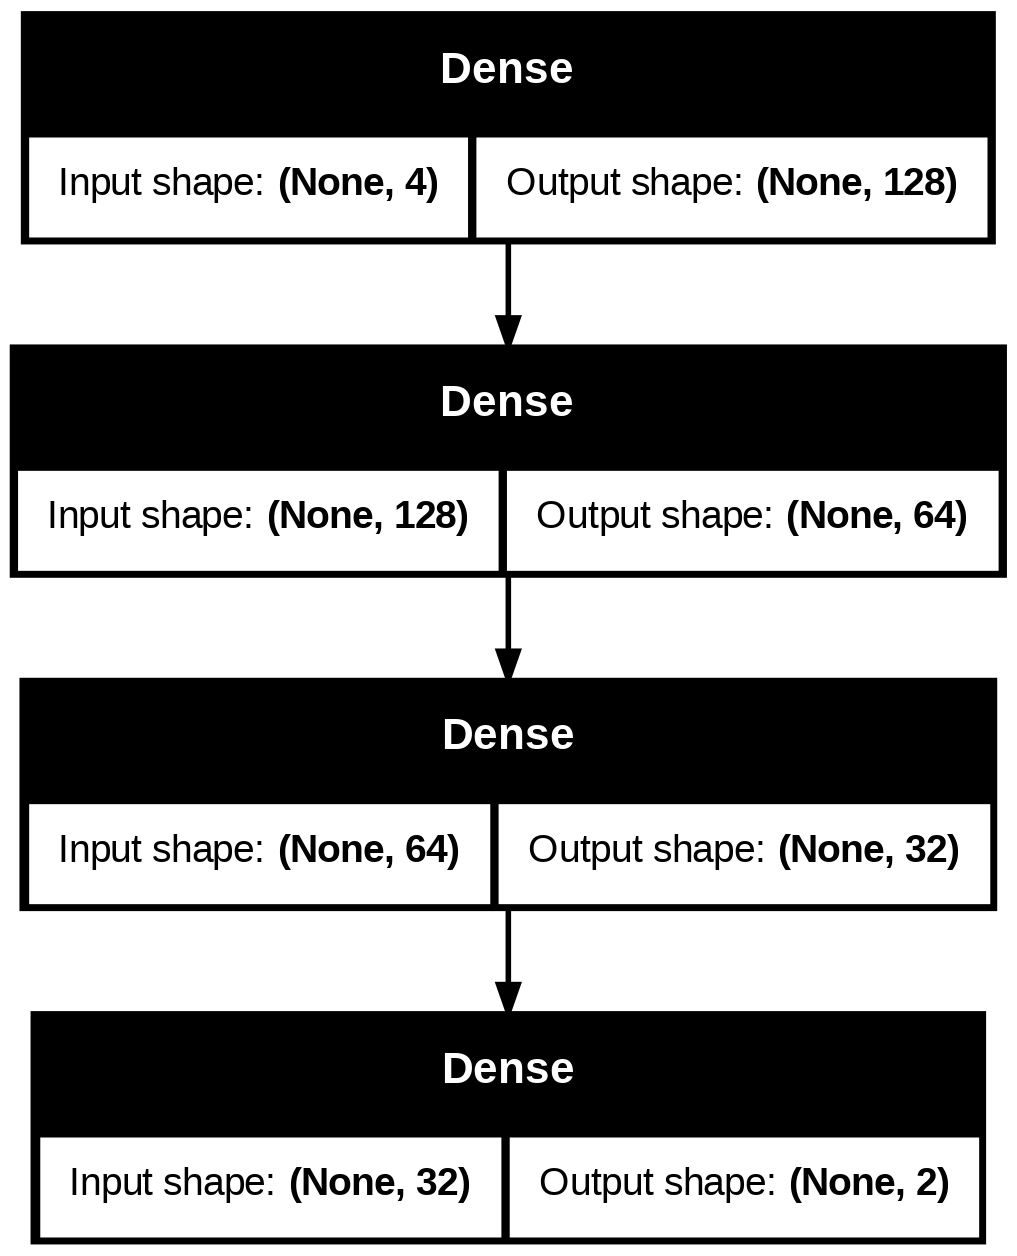

In [17]:
from tensorflow.keras.utils import plot_model
plot_model(model, show_shapes = True)

In [18]:
history = model.fit(X_train, y_train,
                    epochs=50,
                    batch_size=16,
                    validation_data=(X_test, y_test))

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.7375 - loss: 0.6604 - val_accuracy: 0.7619 - val_loss: 0.5936
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7310 - loss: 0.5986 - val_accuracy: 0.7619 - val_loss: 0.5333
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7916 - loss: 0.5242 - val_accuracy: 0.7619 - val_loss: 0.4833
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7276 - loss: 0.5270 - val_accuracy: 0.7619 - val_loss: 0.4424
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7410 - loss: 0.4852 - val_accuracy: 0.7619 - val_loss: 0.3955
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7373 - loss: 0.4726 - val_accuracy: 0.7619 - val_loss: 0.3512
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7593 - loss: 0.4326 - val_accuracy: 0.9048 - val_loss: 0.3075
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7834 - loss: 0.3782 - val_accuracy: 0.9048 - val_loss: 0.2679


# Evaluation

In [19]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"Akurasi Model: {test_accuracy:.4f}")
print(f"Loss Model: {test_loss:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 1.0000 - loss: 0.0174
Akurasi Model: 1.0000
Loss Model: 0.0174


In [20]:
plt.figure(figsize=(12, 5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

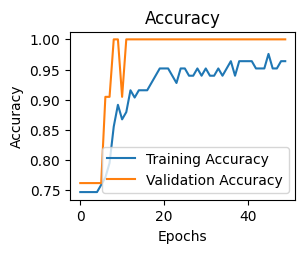

In [21]:
plt.subplot(2, 2, 4)
plt.plot(history.history["accuracy"], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy')

plt.show()

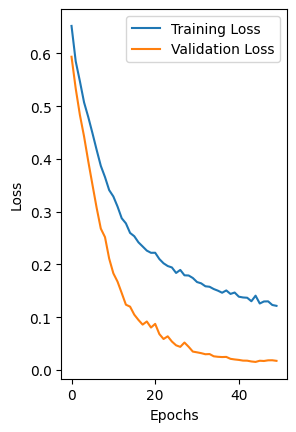

In [22]:
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


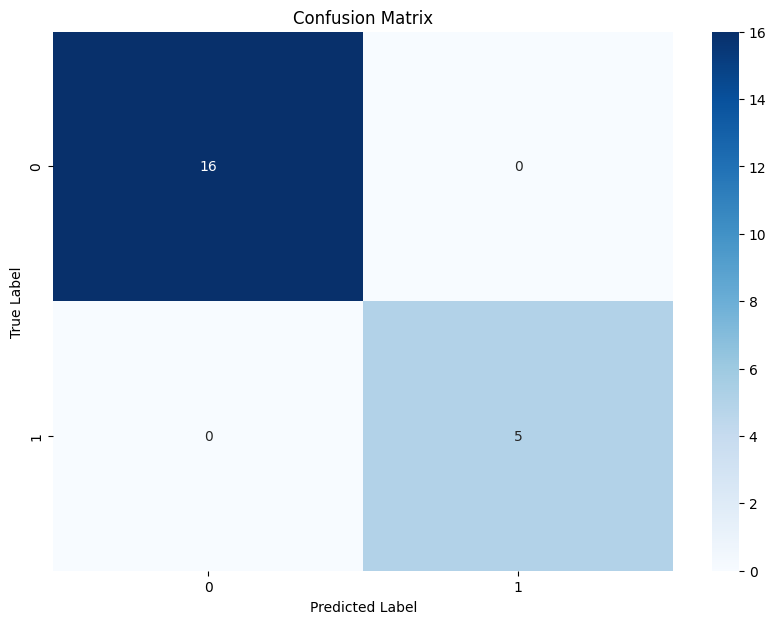

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      1.00      1.00         5

    accuracy                           1.00        21
   macro avg       1.00      1.00      1.00        21
weighted avg       1.00      1.00      1.00        21



In [23]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

print("Classification Report:")
print(classification_report(y_test, y_pred_classes))

# Deployment

## Model Simulation

In [24]:
sample_input = np.array([[41.2222, 26.15 ,23.7888, 15]])
sample_input_df = pd.DataFrame(sample_input)

In [25]:
sample_input_scaled = scaler.transform(sample_input_df)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [26]:
predicted_class = np.argmax(model.predict(sample_input_scaled))
predicted_crop = le.inverse_transform([predicted_class])

print(f"Apakah terdiagnosa Anemia: {predicted_crop[0]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
Apakah terdiagnosa Anemia: No


## Save Model

In [27]:
# Konversi model ke TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Simpan model
with open('anaemia-prediction.tflite', 'wb') as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmp6wdbee4n'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 4), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  131923962245968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131923962247888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131922264770128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131922264770512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131923962249040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131923962247312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131922264770896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131922264770320: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [28]:
# Simpan label encoder dan scaler
import joblib
joblib.dump(le, 'label_encoder.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']